#  Email Phishing Detection — Stage 1: TF-IDF + XGBoost

**Dataset:** Kaggle Email Phishing Dataset (~18.6k samples)  
**Task:** Binary classification — `Phishing Email` vs `Safe Email`  
**Goal:** Fast, deployable baseline. Runs on CPU in ~2 minutes.  
**Output:** `email_tfidf_xgboost.pkl` — sklearn Pipeline (vectorizer + model bundled)

---
### Label encoding used throughout
- `0` → Safe Email  
- `1` → Phishing Email

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42

print('All imports successful ✅')

All imports successful ✅


## 2. Load & Inspect Data

In [3]:
df = pd.read_csv('Phishing_Email.csv')

# Drop unnamed index column if present
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (18650, 2)
Columns: ['Email Text', 'Email Type']


,Email Text,Email Type
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,the other side of * galicismos * * galicismo *...,Safe Email
2,re : equistar deal tickets are you still avail...,Safe Email
3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [4]:
# Standardise column names defensively
df.columns = [c.strip() for c in df.columns]

# Expected: 'Email Text', 'Email Type'
print('Class distribution:')
print(df['Email Type'].value_counts())
print(f'\nMissing values:\n{df.isnull().sum()}')
print(f"\nEmpty email texts: {(df['Email Text'].fillna('').str.strip() == '').sum()}")

Class distribution:
Email Type
Safe Email        11322
Phishing Email     7328
Name: count, dtype: int64

Missing values:
Email Text    16
Email Type     0
dtype: int64

Empty email texts: 19


## 3. Preprocessing

In [5]:
def clean_email_text(text):
    """
    Clean raw email body text:
    - Lowercase
    - Strip HTML tags
    - Remove URLs (replaced by token so TF-IDF still sees 'url' as a feature)
    - Remove email addresses
    - Collapse whitespace
    - Drop very short / empty results
    """
    if not isinstance(text, str) or text.strip() == '':
        return ''
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)          # strip HTML tags
    text = re.sub(r'http\S+|www\.\S+', ' urltoken ', text)  # replace URLs
    text = re.sub(r'\S+@\S+', ' emailtoken ', text)          # replace emails
    text = re.sub(r'[^a-z0-9\s]', ' ', text)     # keep only alphanumeric
    text = re.sub(r'\s+', ' ', text).strip()      # collapse whitespace
    return text

# Apply cleaning
df['clean_text'] = df['Email Text'].apply(clean_email_text)

# Encode labels: Phishing Email → 1, Safe Email → 0
df['label'] = (df['Email Type'] == 'Phishing Email').astype(int)

# Drop rows where cleaning resulted in empty strings
before = len(df)
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)
print(f'Dropped {before - len(df)} empty rows. Remaining: {len(df):,}')
print(f'\nLabel distribution after cleaning:')
print(df['label'].value_counts().rename({0: 'Safe (0)', 1: 'Phishing (1)'}))

Dropped 19 empty rows. Remaining: 18,631

Label distribution after cleaning:
label
Safe (0)        11322
Phishing (1)     7309
Name: count, dtype: int64


In [6]:
# Quick sanity check — look at cleaned text
print('=== Sample SAFE email (cleaned) ===')
print(df[df['label']==0]['clean_text'].iloc[0][:300])
print('\n=== Sample PHISHING email (cleaned) ===')
print(df[df['label']==1]['clean_text'].iloc[0][:300])

=== Sample SAFE email (cleaned) ===
re 6 1100 disc uniformitarianism re 1086 sex lang dick hudson s observations on us use of s on but not d aughter as a vocative are very thought provoking but i am not sure that it is fair to attribute this to sons being treated like senior relatives for one thing we do n t normally use brother in th

=== Sample PHISHING email (cleaned) ===
hello i am your hot lil horny toy i am the one you dream about i am a very open minded person love to talk about and any subject fantasy is my way of life ultimate in sex play ummmmmmmmmmmmmm i am wet and ready for you it is not your looks but your imagination that matters most with my sexy voice i 


In [7]:
# Train-test split (stratified)
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'\nTrain label balance:\n{y_train.value_counts().rename({0: "Safe", 1: "Phishing"})}')
print(f'\nTest label balance:\n{y_test.value_counts().rename({0: "Safe", 1: "Phishing"})}')

Train: 14,904  |  Test: 3,727

Train label balance:
label
Safe        9057
Phishing    5847
Name: count, dtype: int64

Test label balance:
label
Safe        2265
Phishing    1462
Name: count, dtype: int64


## 4. EDA — Text Characteristics

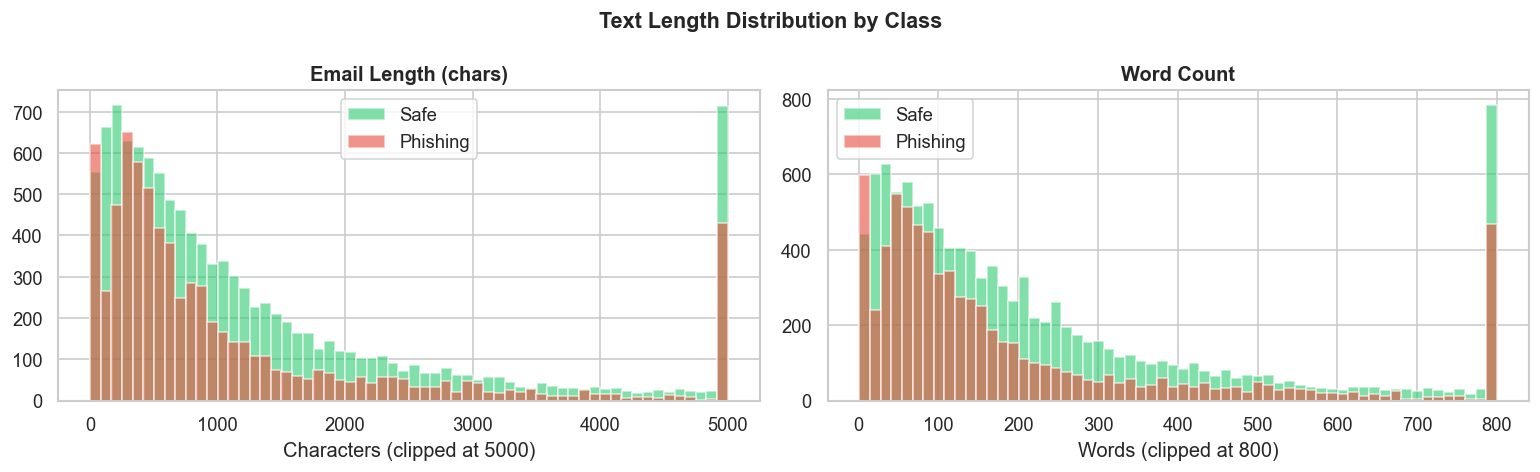

         text_length                                                           \
               count    mean       std  min    25%    50%     75%         max   
label                                                                           
Safe         11322.0  2874.5  121812.7  5.0  376.0  835.5  1762.8  12955520.0   
Phishing      7309.0  1418.7    3046.0  3.0  312.0  619.0  1350.0    123967.0   

         word_count                                                      
              count   mean      std  min   25%    50%    75%        max  
label                                                                    
Safe        11322.0  496.3  20623.0  1.0  68.0  153.0  311.0  2193356.0  
Phishing     7309.0  246.9    472.8  1.0  55.0  110.0  238.0    11744.0  


In [8]:
# Email length distribution by class
df['text_length'] = df['clean_text'].str.len()
df['word_count']  = df['clean_text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
label_names = {0: 'Safe', 1: 'Phishing'}
colors = {0: '#2ECC71', 1: '#E74C3C'}

for label, group in df.groupby('label'):
    axes[0].hist(group['text_length'].clip(upper=5000), bins=60,
                 alpha=0.6, label=label_names[label], color=colors[label])
    axes[1].hist(group['word_count'].clip(upper=800), bins=60,
                 alpha=0.6, label=label_names[label], color=colors[label])

axes[0].set_title('Email Length (chars)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Characters (clipped at 5000)')
axes[0].legend()

axes[1].set_title('Word Count', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Words (clipped at 800)')
axes[1].legend()

plt.suptitle('Text Length Distribution by Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(df.groupby('label')[['text_length', 'word_count']]
        .describe().round(1)
        .rename(index={0: 'Safe', 1: 'Phishing'}))

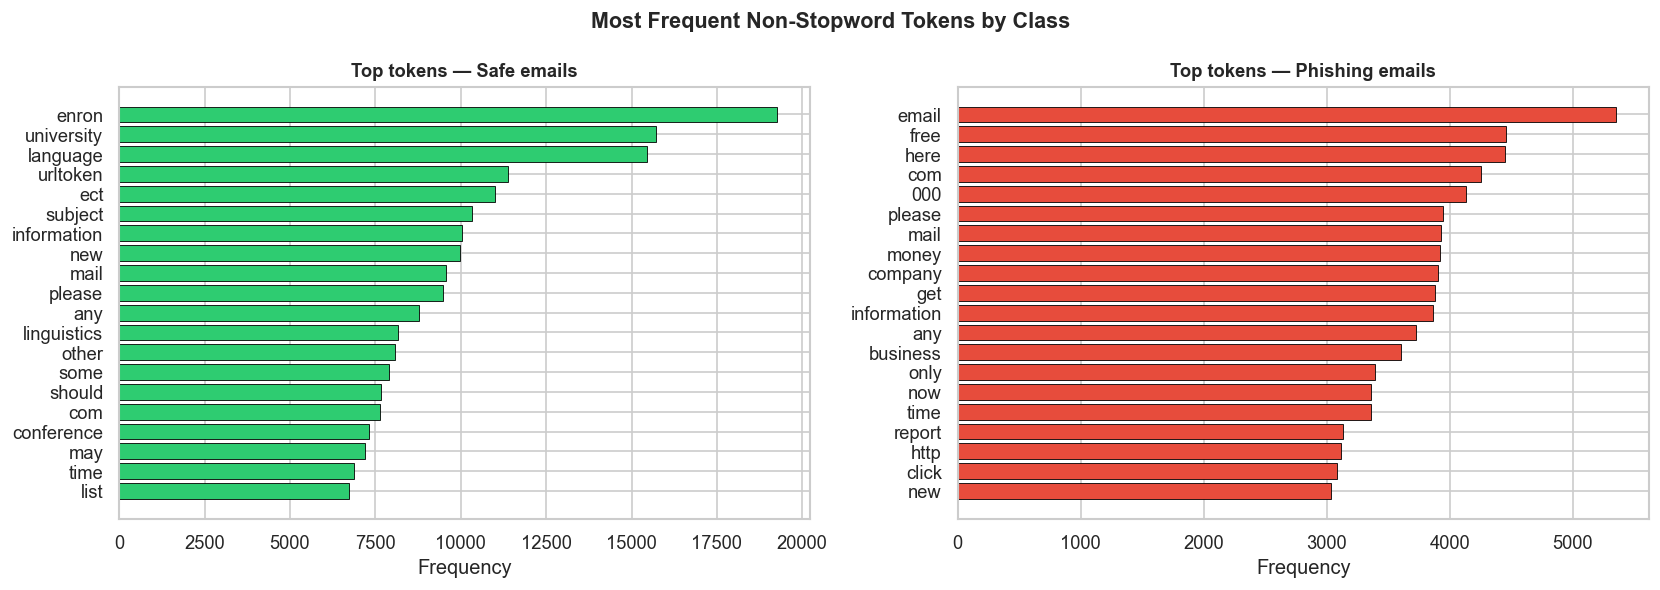

In [9]:
# Top tokens by class (crude frequency before TF-IDF weighting)
from collections import Counter

STOPWORDS = set([
    'the','a','an','and','or','is','are','was','were','be','been',
    'to','of','in','it','that','this','for','with','on','at','by',
    'i','you','we','he','she','they','my','your','our','have','has',
    'do','not','but','from','as','will','so','if','up','about','out',
    'one','all','can','would','there','what','which','his','her','their',
    'me','him','us','them','its','also','than','then','when','no','more'
])

def top_tokens(texts, n=20):
    tokens = [w for t in texts for w in t.split() if w not in STOPWORDS and len(w) > 2]
    return Counter(tokens).most_common(n)

safe_top     = top_tokens(df[df['label']==0]['clean_text'])
phishing_top = top_tokens(df[df['label']==1]['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title, color in [
    (axes[0], safe_top,     'Top tokens — Safe emails',     '#2ECC71'),
    (axes[1], phishing_top, 'Top tokens — Phishing emails', '#E74C3C'),
]:
    words, counts = zip(*data)
    ax.barh(words[::-1], counts[::-1], color=color, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.suptitle('Most Frequent Non-Stopword Tokens by Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Model 1 — TF-IDF + Logistic Regression (baseline)

In [10]:
# ── Helper: evaluate a pipeline ──────────────────────────────────────────────
def evaluate_pipeline(name, pipeline, X_te, y_te):
    y_pred = pipeline.predict(X_te)
    y_prob = pipeline.predict_proba(X_te)[:, 1]
    acc  = accuracy_score(y_te, y_pred)
    auc  = roc_auc_score(y_te, y_prob)
    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  ROC-AUC  : {auc:.4f}')
    print(f'\n{classification_report(y_te, y_pred, target_names=["Safe", "Phishing"])}')
    return {'Model': name, 'Accuracy': acc, 'ROC-AUC': auc,
            'y_pred': y_pred, 'y_prob': y_prob, 'pipeline': pipeline}

In [11]:
# Logistic Regression baseline
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=15000,
        ngram_range=(1, 2),      # unigrams + bigrams
        sublinear_tf=True,       # log(1+tf) — reduces impact of high-freq words
        min_df=3,                # ignore tokens appearing in fewer than 3 docs
        strip_accents='unicode',
    )),
    ('clf', LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE))
])

lr_pipeline.fit(X_train, y_train)
lr_results = evaluate_pipeline('TF-IDF + Logistic Regression', lr_pipeline, X_test, y_test)


  TF-IDF + Logistic Regression
  Accuracy : 0.9665
  ROC-AUC  : 0.9944

              precision    recall  f1-score   support

        Safe       0.98      0.97      0.97      2265
    Phishing       0.95      0.96      0.96      1462

    accuracy                           0.97      3727
   macro avg       0.96      0.97      0.96      3727
weighted avg       0.97      0.97      0.97      3727



## 6. Model 2 — TF-IDF + XGBoost (primary model)

In [12]:
# XGBoost pipeline
# Note: XGBoost doesn't handle scipy sparse directly in all versions,
# so we'll use the DMatrix-compatible path via sklearn API
xgb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=15000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=3,
        strip_accents='unicode',
    )),
    ('clf', XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        tree_method='hist',    # fast histogram method — important for sparse TF-IDF
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

print('Training XGBoost pipeline... (may take 1-3 min on CPU)')
xgb_pipeline.fit(X_train, y_train)
xgb_results = evaluate_pipeline('TF-IDF + XGBoost', xgb_pipeline, X_test, y_test)

Training XGBoost pipeline... (may take 1-3 min on CPU)

  TF-IDF + XGBoost
  Accuracy : 0.9651
  ROC-AUC  : 0.9940

              precision    recall  f1-score   support

        Safe       0.98      0.96      0.97      2265
    Phishing       0.94      0.97      0.96      1462

    accuracy                           0.97      3727
   macro avg       0.96      0.97      0.96      3727
weighted avg       0.97      0.97      0.97      3727



## 7. Comparison

In [13]:
results_list = [lr_results, xgb_results]

# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame([
    {'Model': r['Model'], 'Accuracy': r['Accuracy'], 'ROC-AUC': r['ROC-AUC']}
    for r in results_list
]).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

summary_display = summary.copy()
summary_display['Accuracy'] = summary_display['Accuracy'].map('{:.4f}'.format)
summary_display['ROC-AUC']  = summary_display['ROC-AUC'].map('{:.4f}'.format)
display(summary_display)

,Model,Accuracy,ROC-AUC
0,TF-IDF + Logistic Regression,0.9665,0.9944
1,TF-IDF + XGBoost,0.9651,0.9940


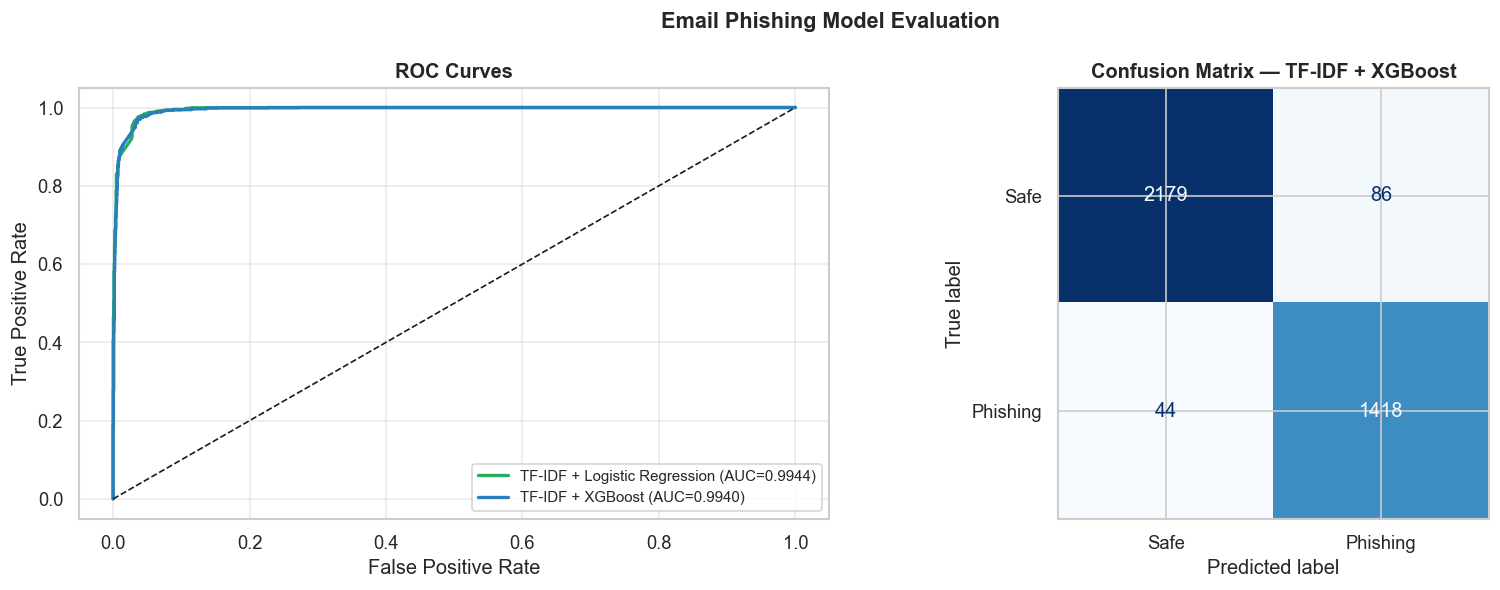

In [14]:
# ── ROC Curves ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = ['#27AE60', '#2980B9']

# ROC
ax = axes[0]
for result, color in zip(results_list, palette):
    fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
    auc = roc_auc_score(y_test, result['y_prob'])
    ax.plot(fpr, tpr, lw=2, color=color, label=f"{result['Model']} (AUC={auc:.4f})")
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_title('ROC Curves', fontsize=12, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.4)

# Confusion matrices side-by-side on right
for i, (result, color) in enumerate(zip(results_list, palette)):
    if i == 0:
        ax2 = axes[1]
    # Only show XGBoost confusion matrix in the right panel
    pass

# Show XGBoost confusion matrix (the one we're saving)
cm = confusion_matrix(y_test, xgb_results['y_pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=['Safe', 'Phishing'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix — TF-IDF + XGBoost', fontsize=12, fontweight='bold')

plt.suptitle('Email Phishing Model Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Cross-Validation

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_models = [
    ('TF-IDF + Logistic Regression', lr_pipeline),
    ('TF-IDF + XGBoost',             xgb_pipeline),
]

cv_results = {}
for name, pipeline in cv_models:
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:40s}  CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}')

print('\nDone ✅')

TF-IDF + Logistic Regression              CV Accuracy: 0.9700 ± 0.0023


KeyboardInterrupt: 

## 9. TF-IDF Feature Analysis

Understanding which tokens the model finds most discriminative — this feeds directly into the explainability layer.

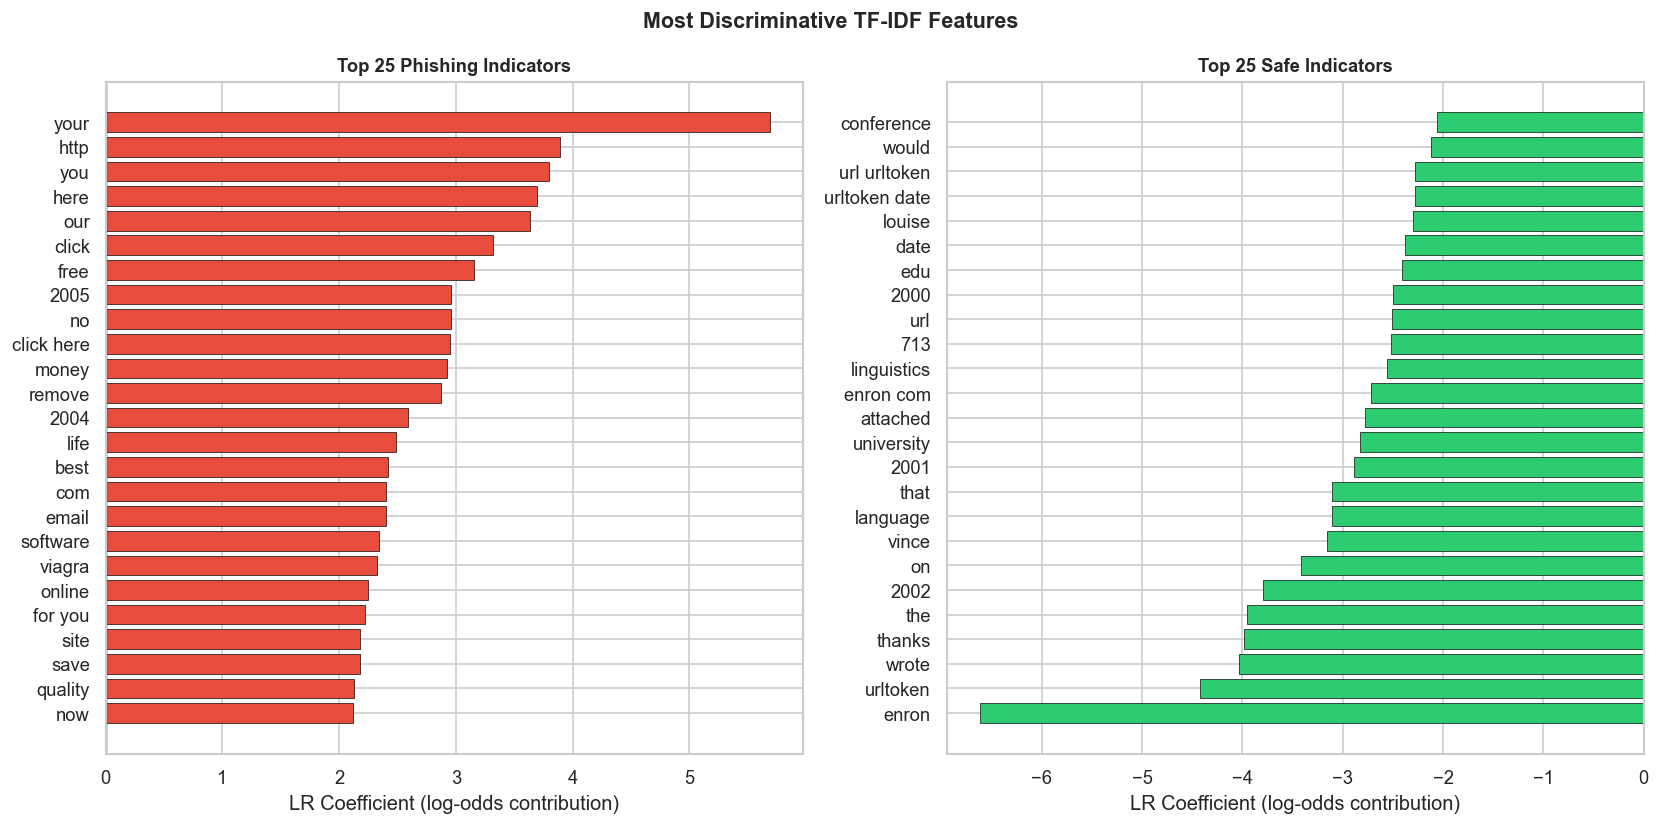

In [16]:
# Top TF-IDF features by LR coefficient
# (XGBoost on sparse TF-IDF doesn't give clean feature importances;
# LR coefficients are the interpretable proxy for both)
vectorizer = lr_pipeline.named_steps['tfidf']
lr_clf     = lr_pipeline.named_steps['clf']

feature_names = vectorizer.get_feature_names_out()
coefficients  = lr_clf.coef_[0]

# Top phishing indicators (positive coefficients → class 1)
top_phishing_idx = np.argsort(coefficients)[-25:]
top_safe_idx     = np.argsort(coefficients)[:25]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, idx, title, color in [
    (axes[0], top_phishing_idx, 'Top 25 Phishing Indicators', '#E74C3C'),
    (axes[1], top_safe_idx,     'Top 25 Safe Indicators',     '#2ECC71'),
]:
    ax.barh(feature_names[idx], coefficients[idx],
            color=color, edgecolor='black', linewidth=0.4)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('LR Coefficient (log-odds contribution)')
    ax.axvline(0, color='black', linewidth=0.8)

plt.suptitle('Most Discriminative TF-IDF Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Inference Helper & Smoke Test

In [17]:
def predict_email(text, pipeline=xgb_pipeline, threshold=0.5):
    """
    Single-email inference function.
    Returns: dict with label, confidence, and risk_score (0-100).
    This is what the FastAPI endpoint will call.
    """
    cleaned = clean_email_text(text)
    if not cleaned:
        return {'label': 'Unknown', 'confidence': 0.0, 'risk_score': 0}

    prob = pipeline.predict_proba([cleaned])[0][1]  # P(phishing)
    label = 'Phishing' if prob >= threshold else 'Safe'

    return {
        'label':      label,
        'confidence': round(float(prob), 4),
        'risk_score': int(prob * 100)
    }


# ── Smoke tests ───────────────────────────────────────────────────────────────
test_emails = [
    # Clear phishing
    """URGENT: Your account has been suspended! Click here immediately to verify 
    your information or your account will be permanently deleted. 
    http://secure-bank-verify.xyz/login""",

    # Clear safe
    """Hi team, please find attached the Q3 report for review. 
    Let me know if you have any questions. Thanks, David.""",

    # Subtle phishing (social engineering)
    """Congratulations! You have been selected for a $500 Amazon gift card.
    To claim your reward, please confirm your shipping address and payment details 
    within 24 hours at the link below.""",

    # Legitimate business email
    """Following up on our meeting yesterday — I've sent the contract over to legal 
    for review. We should have feedback by end of week. Best regards, Sarah.""",
]

print('=== Smoke Test Results ===')
for i, email in enumerate(test_emails):
    result = predict_email(email)
    label_icon = '🚨' if result['label'] == 'Phishing' else '✅'
    print(f'\nEmail {i+1}: {label_icon} {result["label"]:10s}  '
          f'confidence={result["confidence"]:.3f}  '
          f'risk_score={result["risk_score"]}/100')
    print(f'  Preview: "{email.strip()[:80]}..."')

=== Smoke Test Results ===

Email 1: 🚨 Phishing    confidence=0.840  risk_score=83/100
  Preview: "URGENT: Your account has been suspended! Click here immediately to verify 
    y..."

Email 2: ✅ Safe        confidence=0.001  risk_score=0/100
  Preview: "Hi team, please find attached the Q3 report for review. 
    Let me know if you ..."

Email 3: 🚨 Phishing    confidence=0.703  risk_score=70/100
  Preview: "Congratulations! You have been selected for a $500 Amazon gift card.
    To clai..."

Email 4: ✅ Safe        confidence=0.055  risk_score=5/100
  Preview: "Following up on our meeting yesterday — I've sent the contract over to legal 
  ..."


## 11. Save Model

In [18]:
model_path = 'ModelTraining/models/email_tfidf_xgboost.pkl'
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Save full pipeline (vectorizer + model bundled — no separate vectorizer needed at inference)
with open(model_path, 'wb') as f:
    pickle.dump(xgb_pipeline, f)

print(f'✅ Pipeline saved to: {model_path}')
print(f'   File size: {os.path.getsize(model_path) / 1024 / 1024:.1f} MB')

# Verify reload
with open(model_path, 'rb') as f:
    loaded = pickle.load(f)

loaded_preds = loaded.predict(X_test.iloc[:5])
orig_preds   = xgb_pipeline.predict(X_test.iloc[:5])
assert (loaded_preds == orig_preds).all(), 'Mismatch after reload!'

print('\n── Reload verification (5 samples) ──')
for i, (pred, actual) in enumerate(zip(loaded_preds, y_test.iloc[:5])):
    label_map = {0: 'Safe', 1: 'Phishing'}
    match = '✅' if pred == actual else '❌'
    print(f'  Sample {i+1}: Actual={label_map[actual]:10s}  Predicted={label_map[pred]:10s}  {match}')

print('\n✅ Pipeline reload verified — pkl is valid.')
print('\n── What is inside the pipeline ──')
for step_name, step_obj in loaded.steps:
    print(f'  {step_name}: {type(step_obj).__name__}')

✅ Pipeline saved to: ModelTraining/models/email_tfidf_xgboost.pkl
   File size: 1.1 MB

── Reload verification (5 samples) ──
  Sample 1: Actual=Safe        Predicted=Safe        ✅
  Sample 2: Actual=Safe        Predicted=Safe        ✅
  Sample 3: Actual=Safe        Predicted=Safe        ✅
  Sample 4: Actual=Phishing    Predicted=Phishing    ✅
  Sample 5: Actual=Safe        Predicted=Safe        ✅

✅ Pipeline reload verified — pkl is valid.

── What is inside the pipeline ──
  tfidf: TfidfVectorizer
  clf: XGBClassifier


## 12. Summary

| | TF-IDF + LR | TF-IDF + XGBoost ✅ |
|---|---|---|
| Type | Linear baseline | Ensemble boosting |
| Vectorizer | TF-IDF 15k features, bigrams | Same |
| Pkl structure | Full Pipeline | Full Pipeline |
| Interpretability | LR coefficients (transparent) | Feature importance (indirect) |
| Inference input | Raw email string | Raw email string |
| Inference output | label + confidence + risk_score | Same |

**Next step → Stage 2:** Fine-tune `distilbert-base-uncased` on Colab T4 to push accuracy to ~99% and unlock perplexity-based AI-phishing detection. Use this TF-IDF model as the production fallback.